
# TinyImageNet Compression Benchmark

This notebook compares the teacher, KD student, and INT8 PTQ student on TinyImageNet.

It loads results if they exist, otherwise it falls back to the metrics recorded in this conversation.


In [1]:
import os
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.rcParams.update({'figure.dpi': 160})

OUT_DIR = Path("/data/pjiang18/SLP/ModelCompression/data")
CSV_PATH = OUT_DIR / "tinyimagenet_final_comparison.csv"
FIG_DIR = OUT_DIR / "tinyimagenet_figures"
FIG_DIR.mkdir(exist_ok=True)

teacher_results_path = Path("/data/pjiang18/SLP/ModelCompression/results/tinyimagenet_teacher_results.json")
kd_results_path = Path("/data/pjiang18/SLP/ModelCompression/results/tinyimagenet_kd_student_results.json")
int8_results_path = Path("/data/pjiang18/SLP/ModelCompression/results/tinyimagenet_int8_ptq_results.json")

In [3]:

def load_json_strict(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing results file: {path}")
    with open(path, "r") as f:
        return json.load(f)

teacher = load_json_strict(teacher_results_path)
kd = load_json_strict(kd_results_path)
int8 = load_json_strict(int8_results_path)

def safe_div(a, b):
    return a / b if (a is not None and b not in [None, 0]) else np.nan

teacher_params = teacher.get("teacher_params_M", teacher.get("params_M"))
student_params = kd.get("student_params_M")

rows = [
    {
        "model": "Teacher ResNet50",
        "model_type": "teacher",
        "benchmark_acc": teacher.get("benchmark_acc"),
        "benchmark_loss": teacher.get("benchmark_loss"),
        "best_val_acc": teacher.get("best_val_acc"),
        "best_val_loss": teacher.get("best_val_loss"),
        "best_epoch": teacher.get("best_epoch"),
        "train_time_sec": teacher.get("total_train_time_sec"),
        "wall_time_sec": teacher.get("total_wall_time_sec"),
        "peak_mem_gb": teacher.get("peak_mem_gb"),
        "params_M": teacher.get("teacher_params_M", teacher.get("params_M", np.nan)),
        "size_mb": np.nan,
        "latency_ms": np.nan,
        "throughput_img_s": np.nan,
        "compression_vs_teacher": 1.0,
        "note": "Reference model",
    },
    {
        "model": "KD Student ResNet18",
        "model_type": "student_kd",
        "benchmark_acc": int8.get("float_student_acc"),
        "benchmark_loss": int8.get("float_student_loss"),
        "best_val_acc": kd.get("best_val_acc"),
        "best_val_loss": kd.get("best_val_loss"),
        "best_epoch": kd.get("best_epoch"),
        "train_time_sec": kd.get("total_train_time_sec"),
        "wall_time_sec": kd.get("total_wall_time_sec"),
        "peak_mem_gb": kd.get("peak_mem_gb"),
        "params_M": kd.get("student_params_M", np.nan),
        "size_mb": int8.get("float_student_size_mb"),
        "latency_ms": int8.get("float_student_latency_ms"),
        "throughput_img_s": int8.get("float_student_throughput_img_s"),
        "compression_vs_teacher": safe_div(teacher_params, kd.get("student_params_M", np.nan)),
        "note": "Plain KD student",
    },
    {
        "model": "INT8 Student ResNet18",
        "model_type": "student_int8",
        "benchmark_acc": int8.get("quant_student_acc"),
        "benchmark_loss": int8.get("quant_student_loss"),
        "best_val_acc": np.nan,
        "best_val_loss": np.nan,
        "best_epoch": np.nan,
        "train_time_sec": np.nan,
        "wall_time_sec": np.nan,
        "peak_mem_gb": np.nan,
        "params_M": kd.get("student_params_M", np.nan),
        "size_mb": int8.get("quant_student_size_mb"),
        "latency_ms": int8.get("quant_student_latency_ms"),
        "throughput_img_s": int8.get("quant_student_throughput_img_s"),
        "compression_vs_teacher": safe_div(teacher_params, kd.get("student_params_M", np.nan)),
        "note": "PTQ INT8 student",
    },
]

df = pd.DataFrame(rows)
df.to_csv(CSV_PATH, index=False)

df

,model,model_type,benchmark_acc,benchmark_loss,best_val_acc,best_val_loss,best_epoch,train_time_sec,wall_time_sec,peak_mem_gb,params_M,size_mb,latency_ms,throughput_img_s,compression_vs_teacher,note
0,Teacher ResNet50,teacher,82.19,1.437785,81.89,1.458641,150.0,10228.648200,10753.585319,17.442831,NaN,NaN,NaN,NaN,1.0,Reference model
1,KD Student ResNet18,student_kd,70.70,1.414503,69.48,2.013421,89.0,6104.825315,6411.526318,6.999970,11.279112,43.100393,11.804691,92.175813,NaN,Plain KD student
2,INT8 Student ResNet18,student_int8,70.37,1.432219,NaN,NaN,NaN,NaN,NaN,NaN,11.279112,10.886080,5.433608,217.784441,NaN,PTQ INT8 student


In [4]:
print("TEACHER (ResNet50)")
print(f"Best Val Accuracy   : {teacher['best_val_acc']:.2f}%")
print(f"Best Val Loss       : {teacher['best_val_loss']:.4f}")
print(f"Best Epoch          : {teacher['best_epoch']}")
print(f"Train Time          : {teacher['total_train_time_sec']/3600:.2f} hrs")
print(f"Peak Memory         : {teacher['peak_mem_gb']:.2f} GB")

print("\nBenchmark")
print(f"Benchmark Accuracy  : {teacher['benchmark_acc']:.2f}%")
print(f"Benchmark Loss      : {teacher['benchmark_loss']:.4f}")

TEACHER (ResNet50)
Best Val Accuracy   : 81.89%
Best Val Loss       : 1.4586
Best Epoch          : 150
Train Time          : 2.84 hrs
Peak Memory         : 17.44 GB

Benchmark
Benchmark Accuracy  : 82.19%
Benchmark Loss      : 1.4378


In [5]:
print("\n KD STUDENT (ResNet18)")
print(f"Best Val Accuracy   : {kd['best_val_acc']:.2f}%")
print(f"Best Val Loss       : {kd['best_val_loss']:.4f}")
print(f"Best Epoch          : {kd['best_epoch']}")
print(f"Train Time          : {kd['total_train_time_sec']/3600:.2f} hrs")
print(f"Peak Memory         : {kd['peak_mem_gb']:.2f} GB")

print("\nBenchmark")
print(f"Benchmark Accuracy  : {int8['float_student_acc']:.2f}%")
print(f"Benchmark Loss      : {int8['float_student_loss']:.4f}")

print("\nInference")
print(f"Latency             : {int8['float_student_latency_ms']:.2f} ms/img")
print(f"Throughput          : {int8['float_student_throughput_img_s']:.2f} img/s")
print(f"Model Size          : {int8['float_student_size_mb']:.2f} MB")


 KD STUDENT (ResNet18)
Best Val Accuracy   : 69.48%
Best Val Loss       : 2.0134
Best Epoch          : 89
Train Time          : 1.70 hrs
Peak Memory         : 7.00 GB

Benchmark
Benchmark Accuracy  : 70.70%
Benchmark Loss      : 1.4145

Inference
Latency             : 11.80 ms/img
Throughput          : 92.18 img/s
Model Size          : 43.10 MB


In [6]:
print("\n INT8 STUDENT (ResNet18 PTQ)")

print("\nBenchmark")
print(f"Benchmark Accuracy  : {int8['quant_student_acc']:.2f}%")
print(f"Benchmark Loss      : {int8['quant_student_loss']:.4f}")

print("\nInference")
print(f"Latency             : {int8['quant_student_latency_ms']:.2f} ms/img")
print(f"Throughput          : {int8['quant_student_throughput_img_s']:.2f} img/s")
print(f"Model Size          : {int8['quant_student_size_mb']:.2f} MB")

print("\nCompression")
print(f"Latency Speedup     : {int8['float_student_latency_ms']/int8['quant_student_latency_ms']:.2f}x")
print(f"Size Reduction      : {int8['float_student_size_mb']/int8['quant_student_size_mb']:.2f}x")
print(f"Accuracy Drop       : {int8['float_student_acc'] - int8['quant_student_acc']:.2f} points")


 INT8 STUDENT (ResNet18 PTQ)

Benchmark
Benchmark Accuracy  : 70.37%
Benchmark Loss      : 1.4322

Inference
Latency             : 5.43 ms/img
Throughput          : 217.78 img/s
Model Size          : 10.89 MB

Compression
Latency Speedup     : 2.17x
Size Reduction      : 3.96x
Accuracy Drop       : 0.33 points


In [7]:
teacher_acc = df.loc[df["model"] == "Teacher ResNet50", "benchmark_acc"].iloc[0]
kd_acc = df.loc[df["model"] == "KD Student ResNet18", "benchmark_acc"].iloc[0]
int8_acc = df.loc[df["model"] == "INT8 Student ResNet18", "benchmark_acc"].iloc[0]

kd_latency = df.loc[df["model"] == "KD Student ResNet18", "latency_ms"].iloc[0]
int8_latency = df.loc[df["model"] == "INT8 Student ResNet18", "latency_ms"].iloc[0]

kd_size = df.loc[df["model"] == "KD Student ResNet18", "size_mb"].iloc[0]
int8_size = df.loc[df["model"] == "INT8 Student ResNet18", "size_mb"].iloc[0]

print(f"Teacher benchmark accuracy: {teacher_acc:.2f}%")
print(f"KD student benchmark accuracy: {kd_acc:.2f}%")
print(f"INT8 benchmark accuracy: {int8_acc:.2f}%")
print()
print(f"KD -> INT8 accuracy drop: {kd_acc - int8_acc:.2f} points")
print(f"KD -> INT8 latency speedup: {kd_latency / int8_latency:.2f}x")
print(f"KD -> INT8 size reduction: {kd_size / int8_size:.2f}x")

Teacher benchmark accuracy: 82.19%
KD student benchmark accuracy: 70.70%
INT8 benchmark accuracy: 70.37%

KD -> INT8 accuracy drop: 0.33 points
KD -> INT8 latency speedup: 2.17x
KD -> INT8 size reduction: 3.96x


In [8]:
comparison_cols = [
    "model", "benchmark_acc", "benchmark_loss", "best_val_acc", "best_val_loss", "best_epoch",
    "train_time_sec", "wall_time_sec", "peak_mem_gb", "params_M", "size_mb", "latency_ms",
    "throughput_img_s", "compression_vs_teacher"
]
comparison = df[comparison_cols].copy()
comparison


,model,benchmark_acc,benchmark_loss,best_val_acc,best_val_loss,best_epoch,train_time_sec,wall_time_sec,peak_mem_gb,params_M,size_mb,latency_ms,throughput_img_s,compression_vs_teacher
0,Teacher ResNet50,82.19,1.437785,81.89,1.458641,150.0,10228.648200,10753.585319,17.442831,NaN,NaN,NaN,NaN,1.0
1,KD Student ResNet18,70.70,1.414503,69.48,2.013421,89.0,6104.825315,6411.526318,6.999970,11.279112,43.100393,11.804691,92.175813,NaN
2,INT8 Student ResNet18,70.37,1.432219,NaN,NaN,NaN,NaN,NaN,NaN,11.279112,10.886080,5.433608,217.784441,NaN


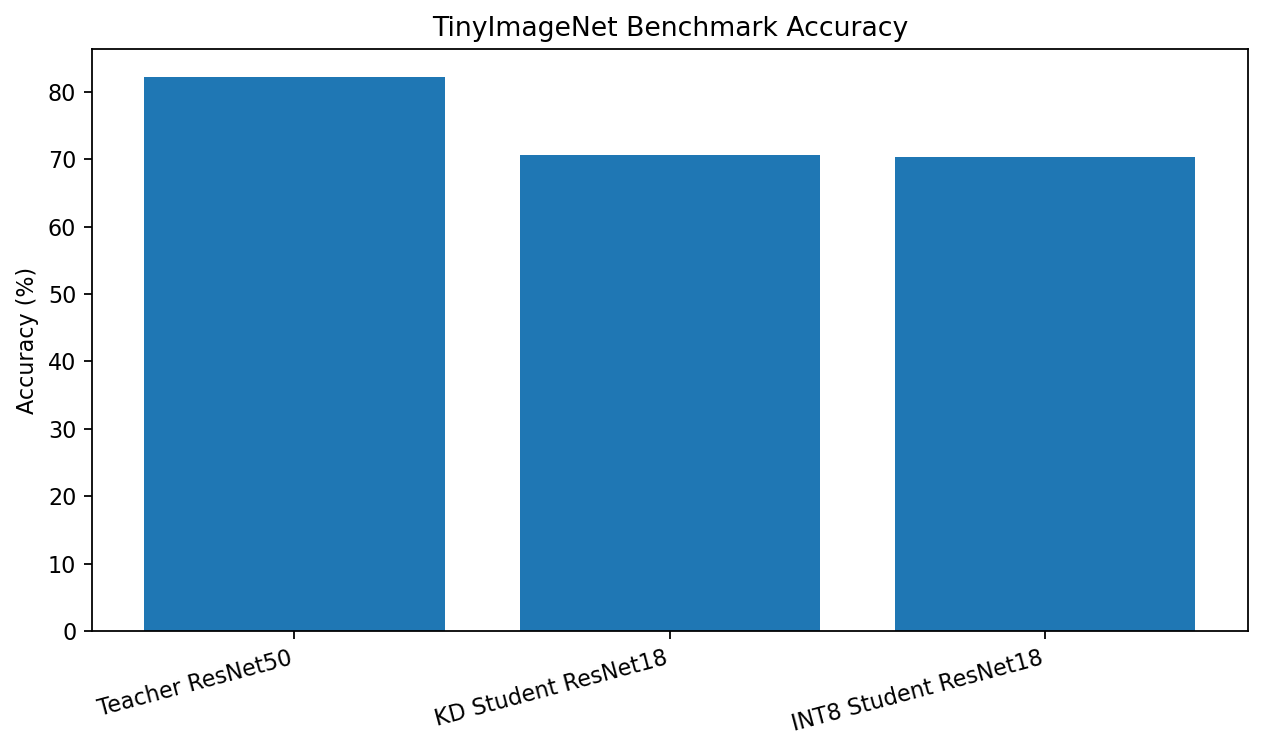

In [9]:
# Plot 1: Benchmark accuracy
fig = plt.figure(figsize=(8, 4.8))
plt.bar(df["model"], df["benchmark_acc"])
plt.ylabel("Accuracy (%)")
plt.title("TinyImageNet Benchmark Accuracy")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "benchmark_accuracy.png", bbox_inches="tight")
plt.show()


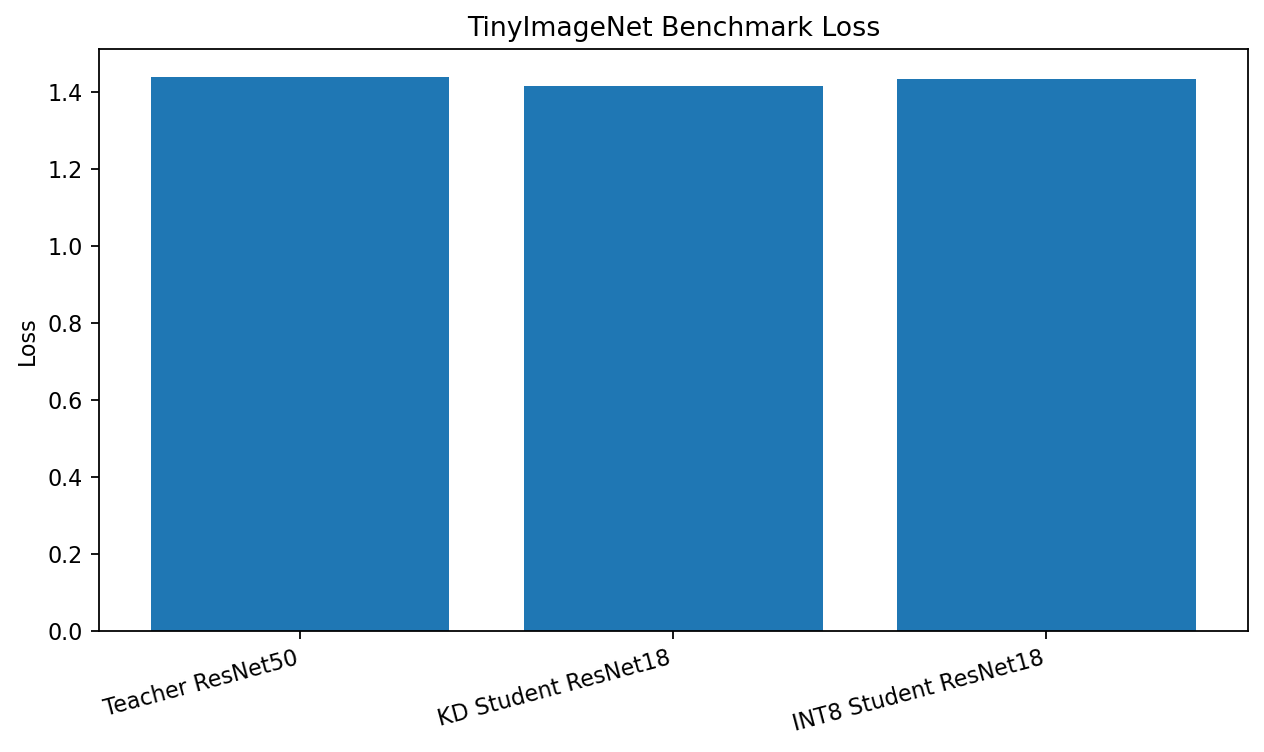

In [10]:
# Plot 2: Benchmark loss
fig = plt.figure(figsize=(8, 4.8))
plt.bar(df["model"], df["benchmark_loss"])
plt.ylabel("Loss")
plt.title("TinyImageNet Benchmark Loss")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "benchmark_loss.png", bbox_inches="tight")
plt.show()


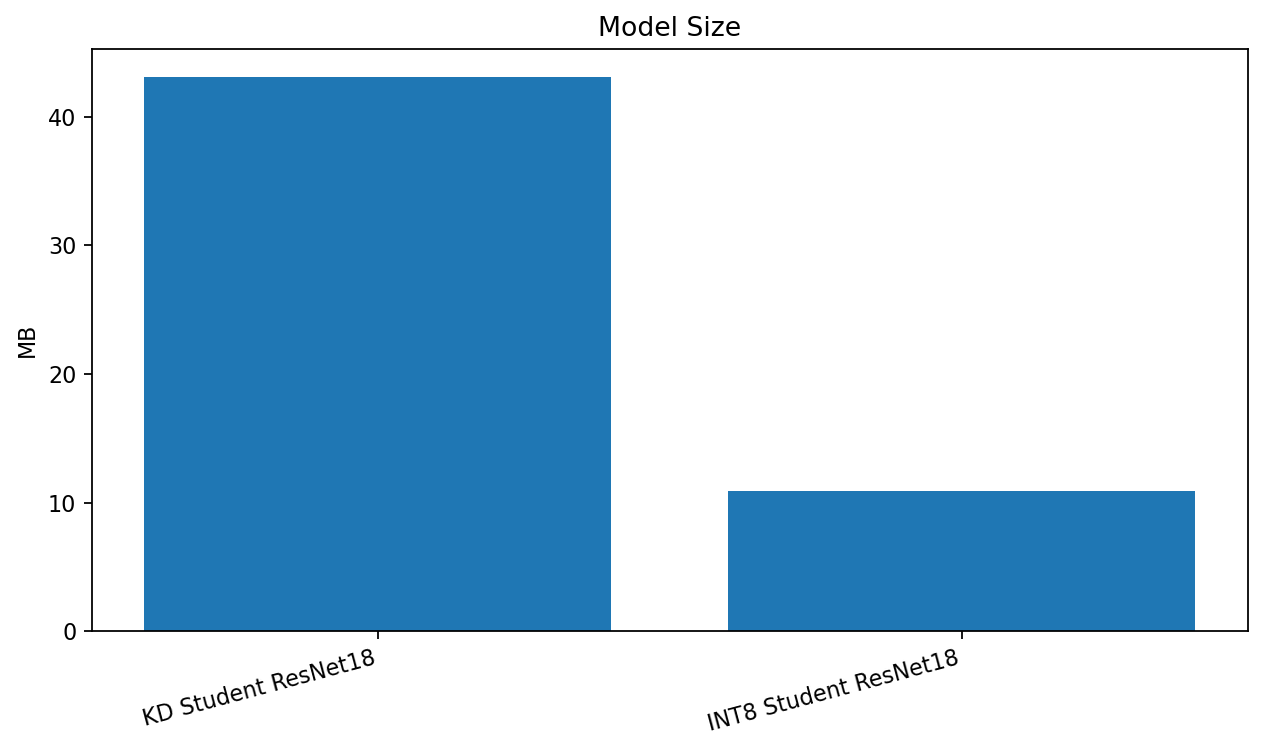

In [11]:
# Plot 3: Model size
fig = plt.figure(figsize=(8, 4.8))
plt.bar(df["model"], df["size_mb"])
plt.ylabel("MB")
plt.title("Model Size")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_size.png", bbox_inches="tight")
plt.show()


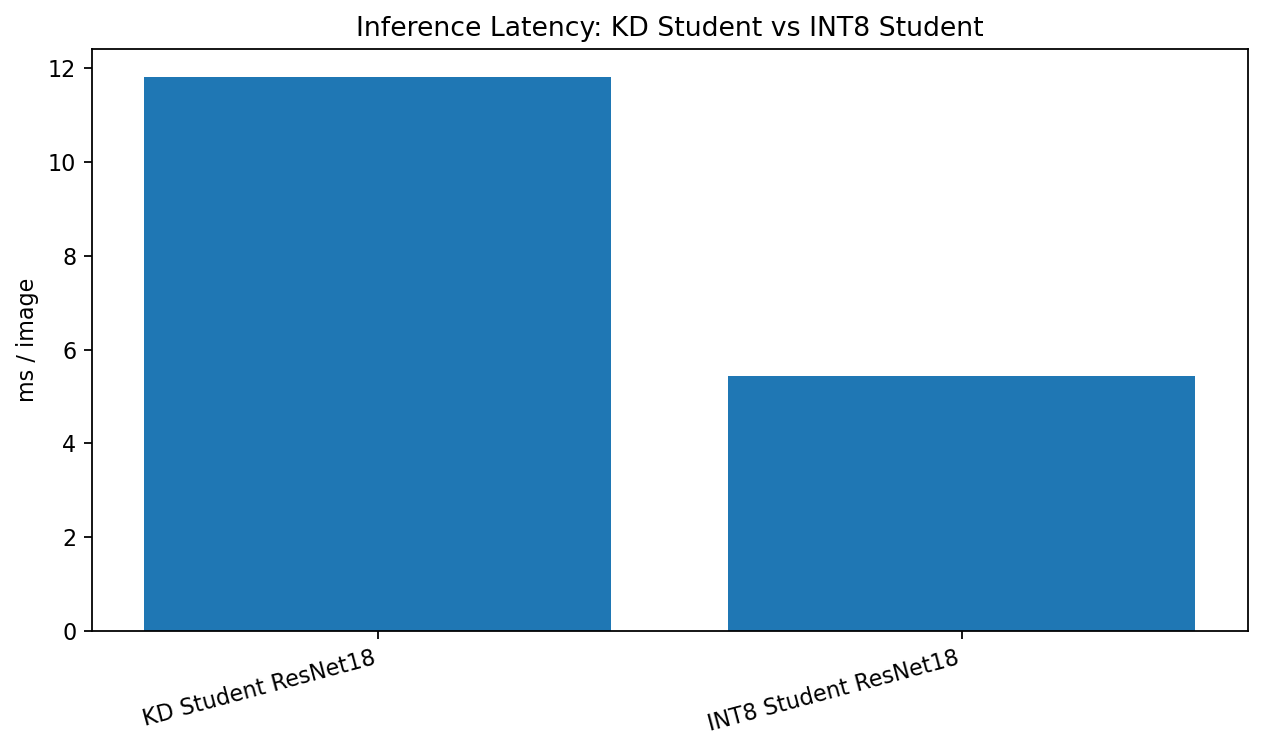

In [12]:
# Plot 4: Latency 
lat_df = df[df["model"].isin(["KD Student ResNet18", "INT8 Student ResNet18"])].copy()
fig = plt.figure(figsize=(8, 4.8))
plt.bar(lat_df["model"], lat_df["latency_ms"])
plt.ylabel("ms / image")
plt.title("Inference Latency: KD Student vs INT8 Student")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "latency_students.png", bbox_inches="tight")
plt.show()


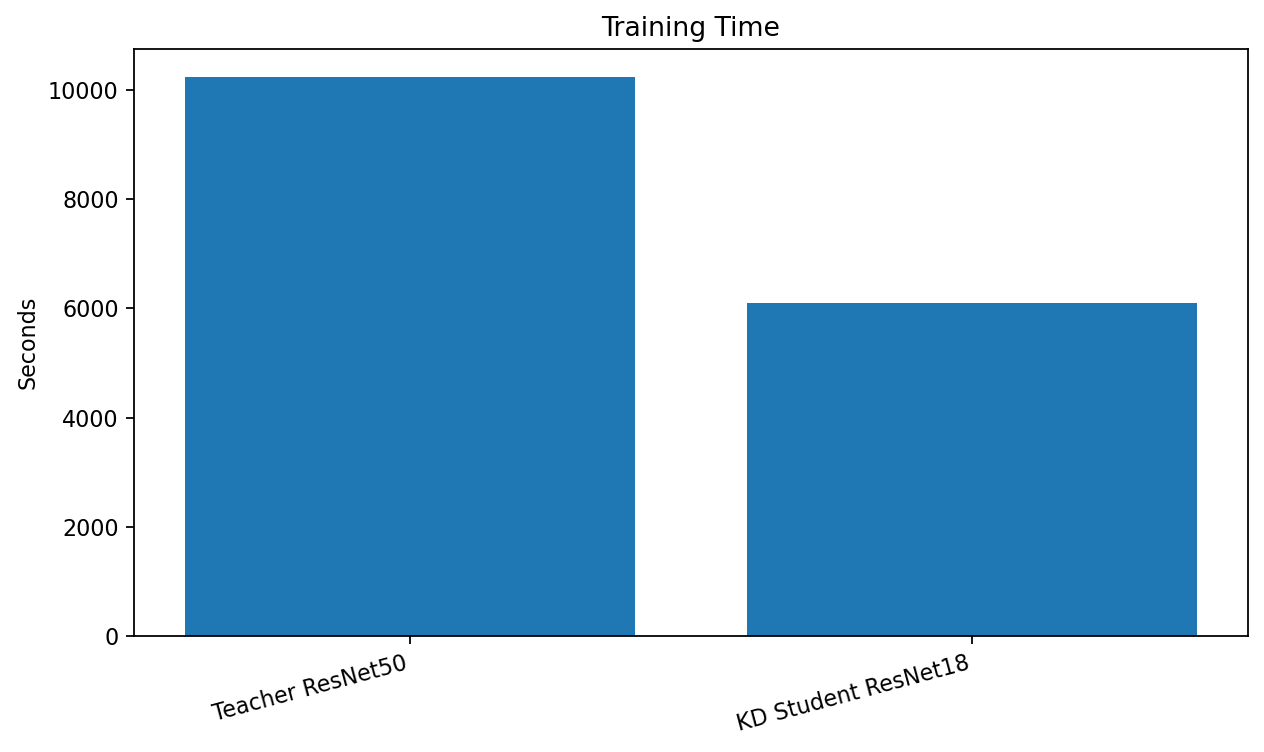

In [13]:

# Plot 5: Training time 
train_df = df[df["model"].isin(["Teacher ResNet50", "KD Student ResNet18"])].copy()
fig = plt.figure(figsize=(8, 4.8))
plt.bar(train_df["model"], train_df["train_time_sec"])
plt.ylabel("Seconds")
plt.title("Training Time")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "training_time.png", bbox_inches="tight")
plt.show()



## Summary

The teacher is the strongest model, as expected. The KD student gives a large reduction in parameter count and training cost, but it drops accuracy substantially. INT8 PTQ is the good part: it keeps the KD student accuracy almost unchanged while cutting latency and size hard. That is the compression win that actually matters.

This project now has a clean story:

- **Teacher ResNet50**: highest accuracy, largest compute cost.
- **KD ResNet18**: much smaller and cheaper, but accuracy drops.
- **INT8 PTQ student**: nearly the same accuracy as the KD student, with much lower latency and a much smaller footprint.


In [14]:

print("CSV:", CSV_PATH)
print("Figures:", FIG_DIR)


CSV: /data/pjiang18/SLP/ModelCompression/data/tinyimagenet_final_comparison.csv
Figures: /data/pjiang18/SLP/ModelCompression/data/tinyimagenet_figures
